🔵 Notes to test

- mean serum protein and the beta-2 microglobulin decreased after treatment, whereas the serum albumin increased (p < 0.01)
- A Wilcoxon test was used to test the difference in textural features before and after treatment connected with -> To address the multiple comparisons, a Benjamin Hochberg correction was applied
- We observed a significant drop of the 1st order textural features “10th percentile” (p = 0.009), “median” (p = 0.01), and “minimum” (p <0.0001) after treatment

In [29]:
import pandas as pd

🔵 Load clinical df

In [ ]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
features_df = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")

clinical_df.head(3)

🔵 Select df before and after treatment

In [31]:
before_patients = ["Myel_012", "Myel_018", "Myel_024", "Myel_059", "Myel_052"]
after_patients = ["Myel_069", "Myel_047", "Myel_023", "Myel_043", "Myel_070"]

clinical_features = ["Beta2 microglobulin (mg/l)", "Serum M-protein quantity (g/l)"]
image_features = ["n_lesions", "original_shape_VoxelVolume", "gradient_firstorder_10Percentile", "original_glcm_Idm", "gradient_firstorder_Median",
                  "gradient_gldm_LowGrayLevelEmphasis"]

features_before = features_df[features_df['patient'].isin(before_patients)][['patient'] + image_features]
clinical_before = clinical_df[clinical_df['Patient ID'].isin(before_patients)][['Patient ID'] + clinical_features]
data_before = pd.merge(clinical_before, features_before, left_on='Patient ID', right_on='patient', how='inner').drop(columns=['patient'])
data_before['Patient ID'] = pd.Categorical(data_before['Patient ID'], categories=before_patients, ordered=True)
data_before = data_before.sort_values('Patient ID').reset_index(drop=True)

features_after = features_df[features_df['patient'].isin(after_patients)][['patient'] + image_features]
clinical_after = clinical_df[clinical_df['Patient ID'].isin(after_patients)][['Patient ID'] + clinical_features]
data_after = pd.merge(clinical_after, features_after, left_on='Patient ID', right_on='patient', how='inner').drop(columns=['patient'])
data_after['Patient ID'] = pd.Categorical(data_after['Patient ID'], categories=after_patients, ordered=True)
data_after = data_after.sort_values('Patient ID').reset_index(drop=True)

In [32]:
data_before

,Patient ID,Beta2 microglobulin (mg/l),Serum M-protein quantity (g/l),n_lesions,original_shape_VoxelVolume,gradient_firstorder_10Percentile,original_glcm_Idm,gradient_firstorder_Median,gradient_gldm_LowGrayLevelEmphasis
0,Myel_012,2.90,51.7,32,8261.366404,20.280259,0.537836,47.865137,0.288840
1,Myel_018,8.21,23.4,25,12251.587393,15.923240,0.586858,36.821598,0.394548
2,Myel_024,1.85,0.0,41,13523.156138,27.837582,0.443981,74.008102,0.173465
3,Myel_059,2.90,0.0,90,61543.580812,21.078676,0.507778,55.349281,0.254719
4,Myel_052,NaN,NaN,76,15433.015057,27.539792,0.465354,62.940819,0.192766


In [33]:
data_after

,Patient ID,Beta2 microglobulin (mg/l),Serum M-protein quantity (g/l),n_lesions,original_shape_VoxelVolume,gradient_firstorder_10Percentile,original_glcm_Idm,gradient_firstorder_Median,gradient_gldm_LowGrayLevelEmphasis
0,Myel_069,1.93,27.4,22,3881.435474,26.717590,0.454965,66.835999,0.190255
1,Myel_047,8.21,23.4,59,32553.118763,18.330799,0.533637,43.958786,0.324903
2,Myel_023,1.60,5.7,40,11243.205191,29.085624,0.431989,72.977173,0.165577
3,Myel_043,3.47,0.0,132,52914.638340,23.452015,0.476061,63.492588,0.217516
4,Myel_070,NaN,NaN,93,29901.169145,21.841930,0.508362,52.963921,0.256160


🔵 mean serum protein and the beta-2 microglobulin decreased after treatment, whereas the serum albumin increased (p < 0.01)

# RADIOMICS FOLLOW UP ANALYSIS

DataFrame preparation

In [11]:
import os
import re
import pandas as pd
from collections import defaultdict


main_folder_path = r"E:\DATA_FollowUp"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]
patients = {img: defaultdict(list) for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))

        folder_path = os.path.join(main_folder_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".csv") and "spine_lesions" in file:
                for img in image_types:
                    if img in file:
                        csv_path = os.path.join(folder_path, file)
                        patients[img][patient_id].append((followup_number, csv_path))

patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

patient_follow_up_dfs = {}

for img_type, patient_data in patients.items():
    patient_follow_up_dfs[img_type] = {}

    for patient, scans in patient_data.items():
        scans = sorted(scans, key=lambda x: x[0])
        dfs = []
        for followup, path in scans:
            df = pd.read_csv(path)
            dfs.append(df)

        patient_df = pd.concat(dfs, ignore_index=True)
        patient_df.insert(0, "Date", patient_dates[patient])
        patient_follow_up_dfs[img_type][patient] = patient_df

Visualization of some features

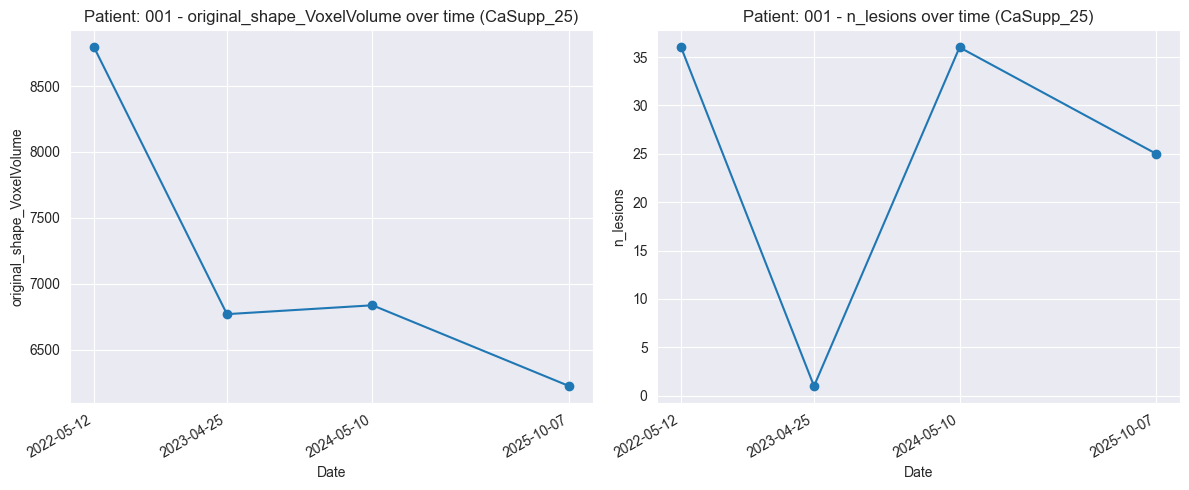

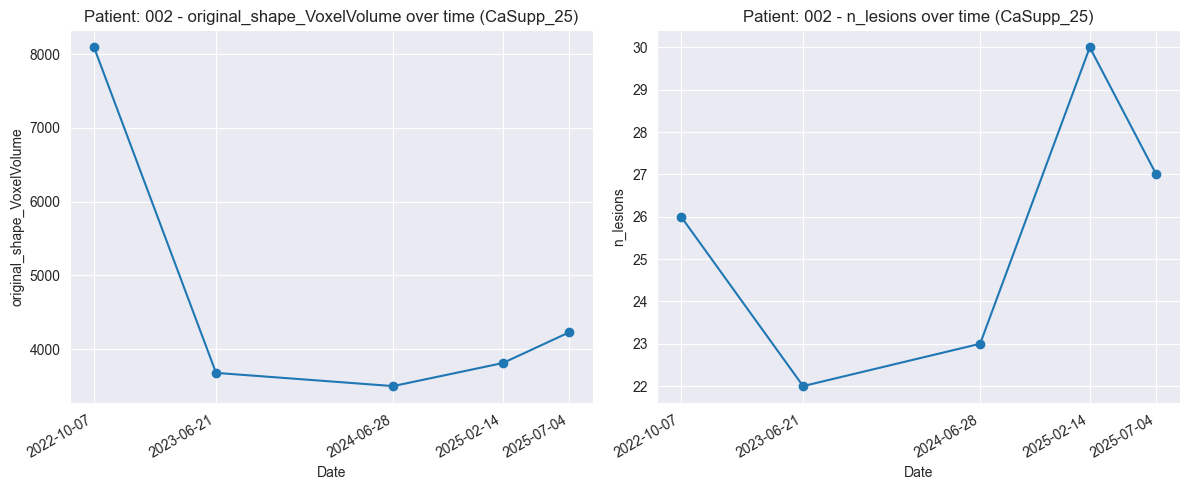

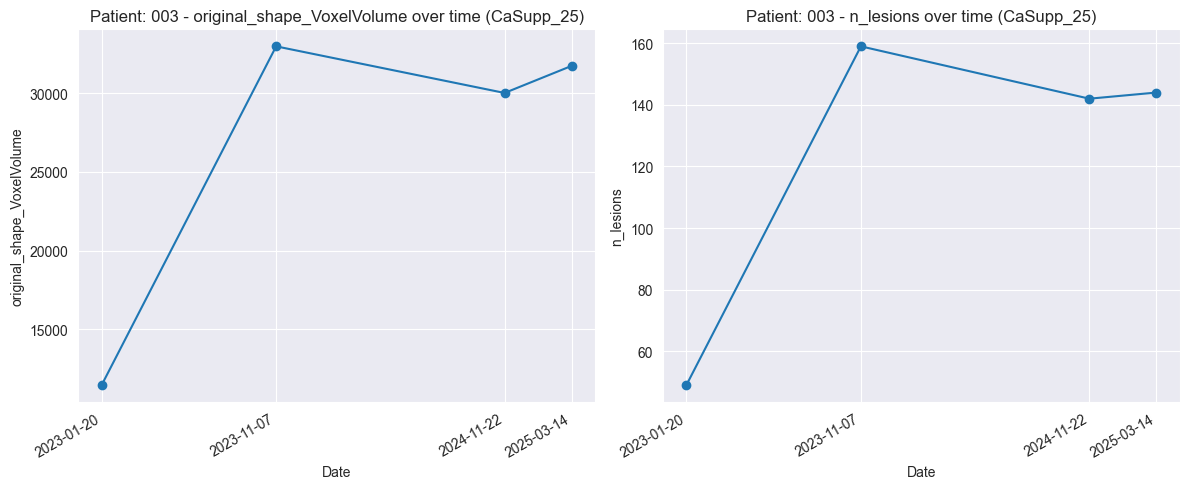

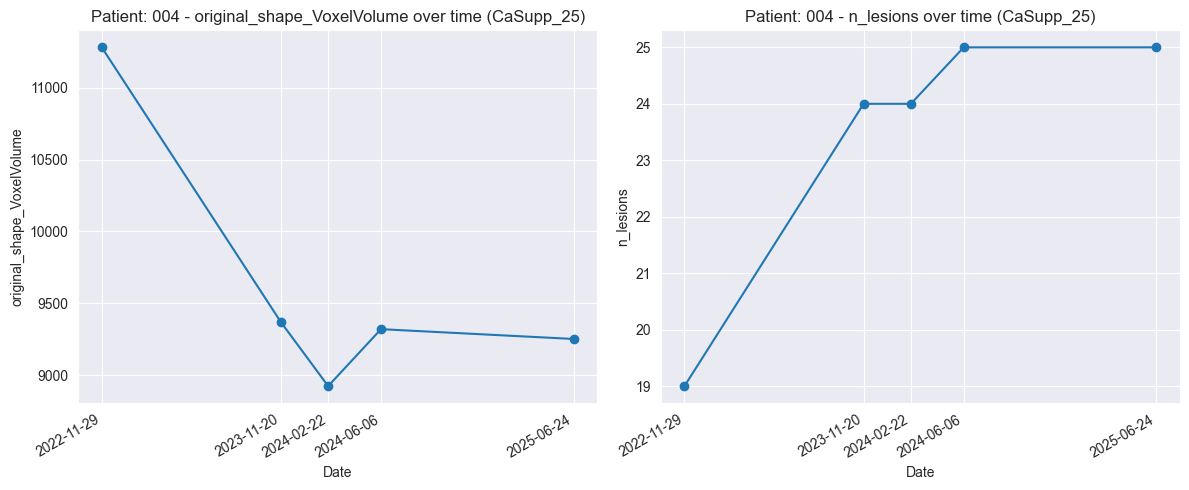

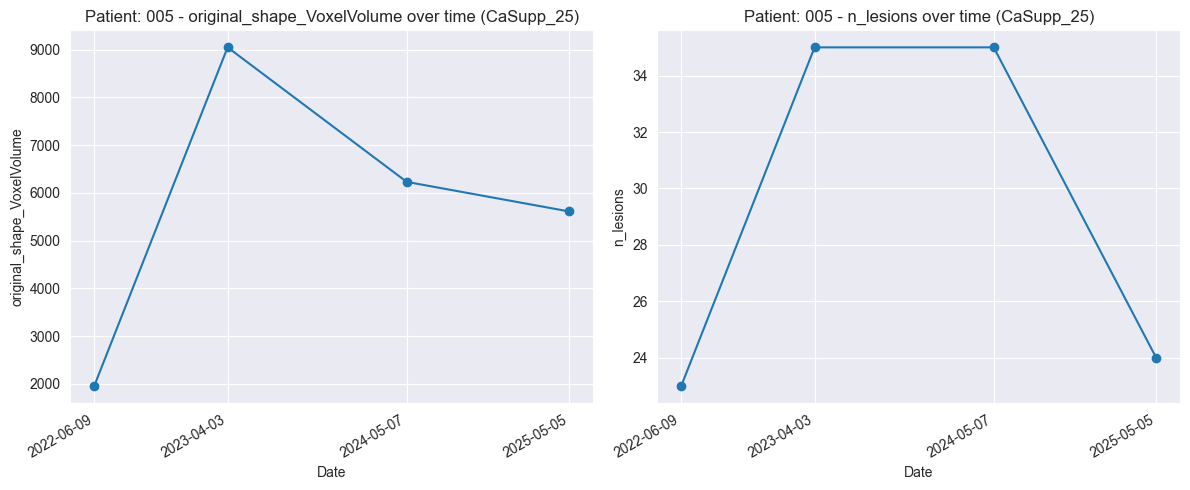

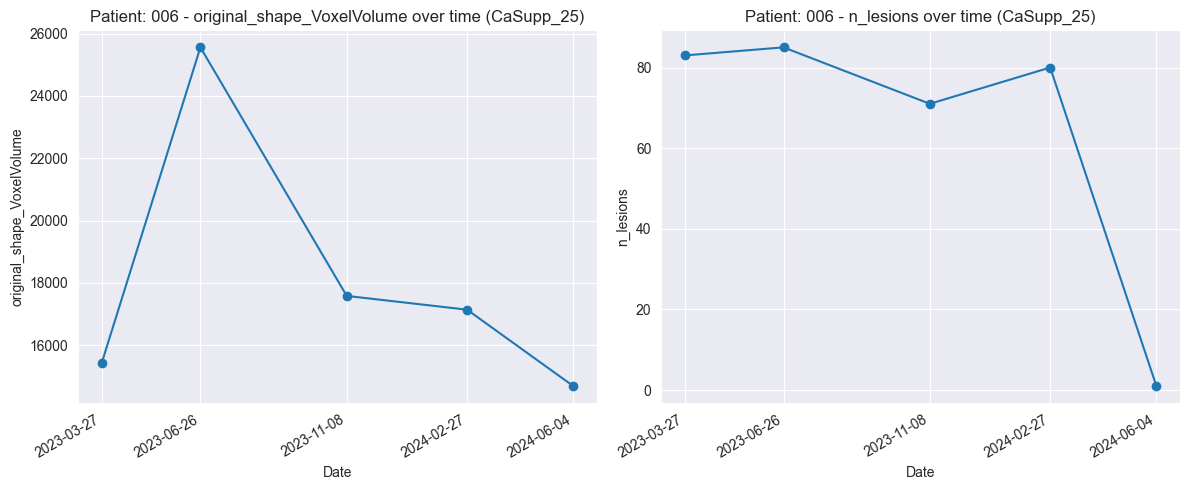

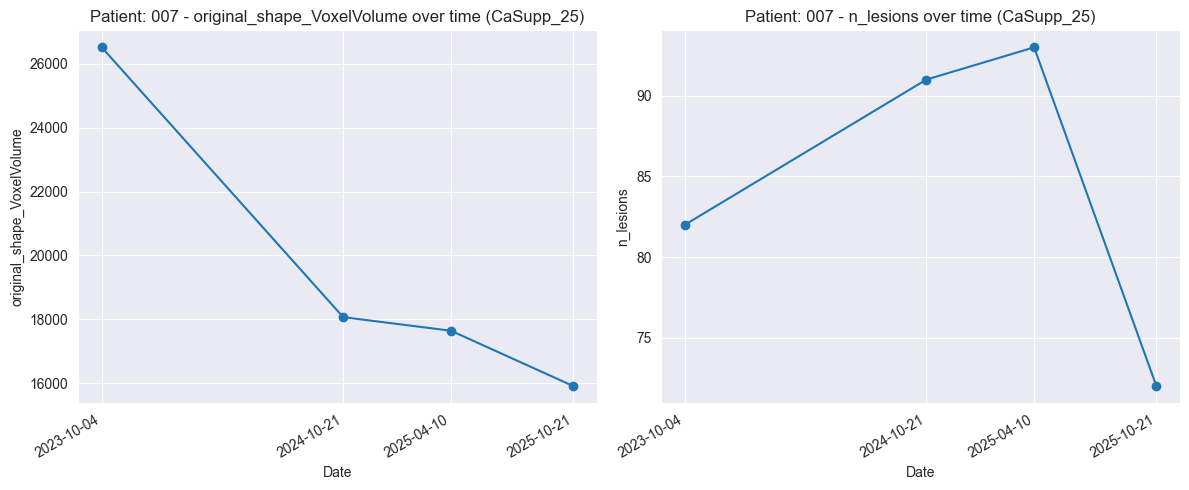

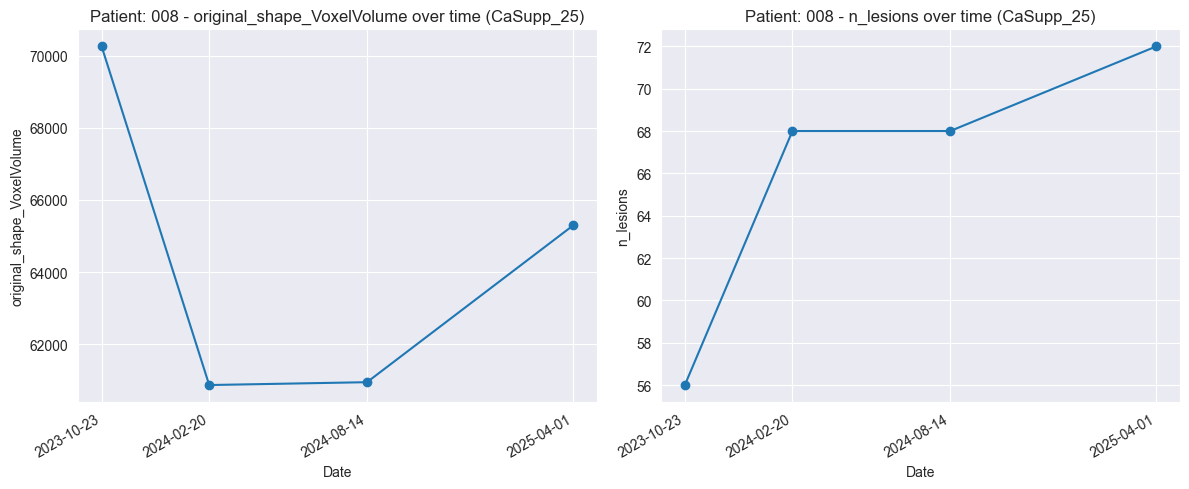

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

image_type = "CaSupp_25"
feature1 = "original_shape_VoxelVolume"
feature2 = "n_lesions"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")

    plt.figure(figsize=(12,5))

    plt.subplot(121)
    plt.plot(df["Date"], df[feature1], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature1)
    plt.title(f"Patient: {patient} - {feature1} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))

    plt.subplot(122)
    plt.plot(df["Date"], df[feature2], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature2)
    plt.title(f"Patient: {patient} - {feature2} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))

    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

Wilcoxon test for radiomics features

In [23]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon
import pandas as pd

wilcoxon_results = {}

for img_type, patient_data in patient_follow_up_dfs.items():

    wilcoxon_results[img_type] = {}
    for patient, df in patient_data.items():
        features = df.columns[1:]
        results = []
        for feature in features:
            values = df[feature].values
            if len(values) < 2:
                continue

            baseline = values[0]
            followups = values[1:]

            baseline_vec = [baseline] * len(followups)
            stat, p = wilcoxon(followups, baseline_vec)

            results.append({
                "Feature": feature,
                "Statistic": stat,
                "P_value": p
            })

        results_df = pd.DataFrame(results)

        if not results_df.empty:
            pvals = results_df["P_value"]
            results_df["FDR_p"] = multipletests(pvals, method="fdr_bh")[1]
            results_df = results_df.sort_values("P_value")

        wilcoxon_results[img_type][patient] = results_df

wilcoxon_results

{'CaSupp_25': {'001':                                     Feature  Statistic  P_value     FDR_p
  2                   original_shape_Flatness        0.0      0.5  0.558333
  6       original_shape_Maximum2DDiameterRow        0.0      0.5  0.558333
  5    original_shape_Maximum2DDiameterColumn        0.0      0.5  0.558333
  4            original_shape_MajorAxisLength        0.0      0.5  0.558333
  7     original_shape_Maximum2DDiameterSlice        0.0      0.5  0.558333
  ..                                      ...        ...      ...       ...
  73    original_glszm_GrayLevelNonUniformity        1.0      1.0  1.000000
  0                                 n_lesions        0.0      1.0  1.000000
  3            original_shape_LeastAxisLength        1.0      1.0  1.000000
  174    gradient_glszm_SizeZoneNonUniformity        1.0      1.0  1.000000
  183   gradient_gldm_DependenceNonUniformity        1.0      1.0  1.000000
  
  [201 rows x 4 columns],
  '002':                               

Kendall trend test

In [4]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import kendalltau
import pandas as pd

kendall_results = {}

for img_type, patient_data in patient_follow_up_dfs.items():

    kendall_results[img_type] = {}
    for patient, df in patient_data.items():
        df = df.copy()
        df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
        df = df.sort_values("Date")

        features = df.columns[1:]  # preskočíme Date
        time_index = range(len(df))
        results = []
        for feature in features:
            values = df[feature].values
            if len(values) < 3:
                continue

            tau, p = kendalltau(time_index, values)
            results.append({
                "Feature": feature,
                "Tau": tau,
                "P_value": p
            })

        results_df = pd.DataFrame(results)

        if not results_df.empty:
            pvals = results_df["P_value"]
            results_df["FDR_p"] = multipletests(pvals, method="fdr_bh")[1]
            results_df = results_df.sort_values("P_value")

        kendall_results[img_type][patient] = results_df

kendall_results

{'CaSupp_25': {'001':                                                Feature       Tau   P_value  \
  0                                            n_lesions -0.816497  0.220671   
  16                    original_firstorder_90Percentile  0.816497  0.220671   
  5               original_shape_Maximum2DDiameterColumn -1.000000  0.333333   
  2                              original_shape_Flatness -1.000000  0.333333   
  7                original_shape_Maximum2DDiameterSlice -1.000000  0.333333   
  ..                                                 ...       ...       ...   
  195  gradient_gldm_SmallDependenceLowGrayLevelEmphasis  0.333333  1.000000   
  194  gradient_gldm_SmallDependenceHighGrayLevelEmph...  0.333333  1.000000   
  193              gradient_gldm_SmallDependenceEmphasis  0.333333  1.000000   
  198                          gradient_ngtdm_Complexity -0.333333  1.000000   
  200                            gradient_ngtdm_Strength -0.333333  1.000000   
  
       FDR_p  
  

In [5]:
def get_significant_features(test_results, img_type, patient_number):
    df = test_results[img_type][patient_number].copy()

    sig = df[df["P_value"] < 0.05].copy()
    sig["Trend"] = sig["Tau"].apply(lambda x: "Increasing" if x > 0 else "Decreasing")

    return sig.sort_values("P_value").head(10)

get_significant_features(kendall_results, "CaSupp_25", "004")

,Feature,Tau,P_value,FDR_p,Trend
25,original_firstorder_Minimum,-1.0,0.016667,0.069792,Decreasing
61,original_glrlm_LongRunEmphasis,-1.0,0.016667,0.069792,Decreasing
42,original_glcm_Id,-1.0,0.016667,0.069792,Decreasing
43,original_glcm_Idm,-1.0,0.016667,0.069792,Decreasing
40,original_glcm_DifferenceEntropy,1.0,0.016667,0.069792,Increasing
41,original_glcm_DifferenceVariance,1.0,0.016667,0.069792,Increasing
37,original_glcm_Contrast,1.0,0.016667,0.069792,Increasing
39,original_glcm_DifferenceAverage,1.0,0.016667,0.069792,Increasing
124,gradient_firstorder_Uniformity,-1.0,0.016667,0.069792,Decreasing
91,original_gldm_DependenceNonUniformityNormalized,1.0,0.016667,0.069792,Increasing


In [6]:
get_significant_features(kendall_results, "CaSupp_25", "004")

,Feature,Tau,P_value,FDR_p,Trend
25,original_firstorder_Minimum,-1.0,0.016667,0.069792,Decreasing
61,original_glrlm_LongRunEmphasis,-1.0,0.016667,0.069792,Decreasing
42,original_glcm_Id,-1.0,0.016667,0.069792,Decreasing
43,original_glcm_Idm,-1.0,0.016667,0.069792,Decreasing
40,original_glcm_DifferenceEntropy,1.0,0.016667,0.069792,Increasing
41,original_glcm_DifferenceVariance,1.0,0.016667,0.069792,Increasing
37,original_glcm_Contrast,1.0,0.016667,0.069792,Increasing
39,original_glcm_DifferenceAverage,1.0,0.016667,0.069792,Increasing
124,gradient_firstorder_Uniformity,-1.0,0.016667,0.069792,Decreasing
91,original_gldm_DependenceNonUniformityNormalized,1.0,0.016667,0.069792,Increasing


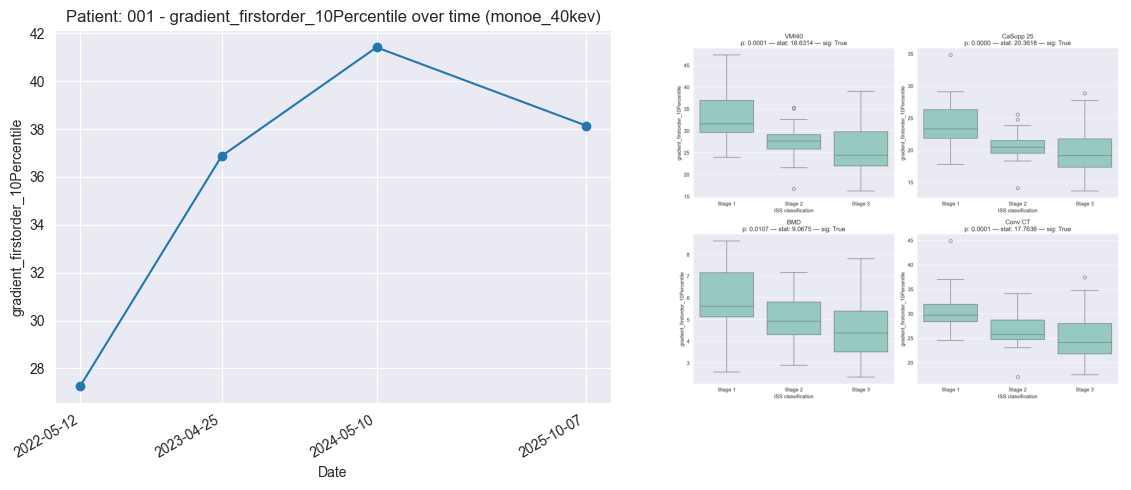

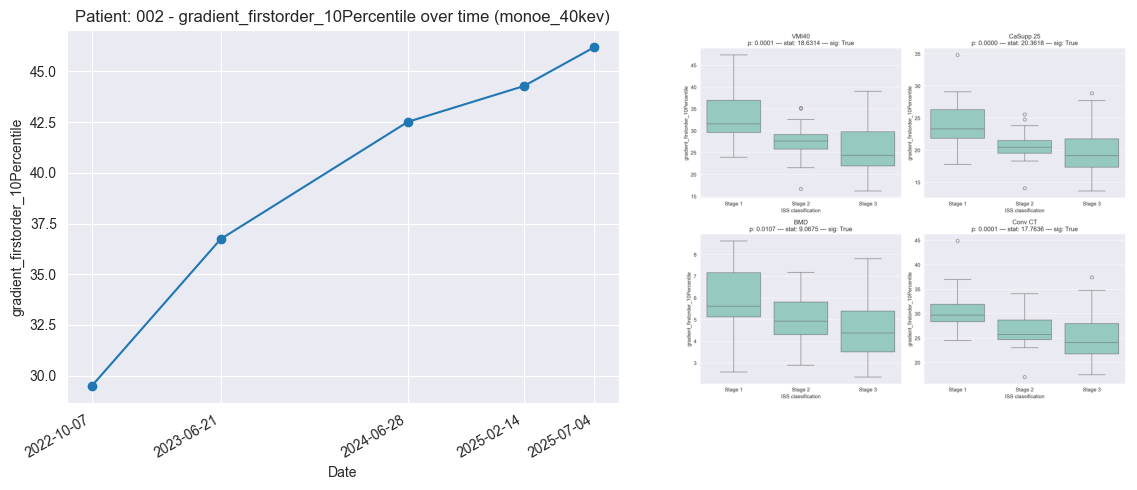

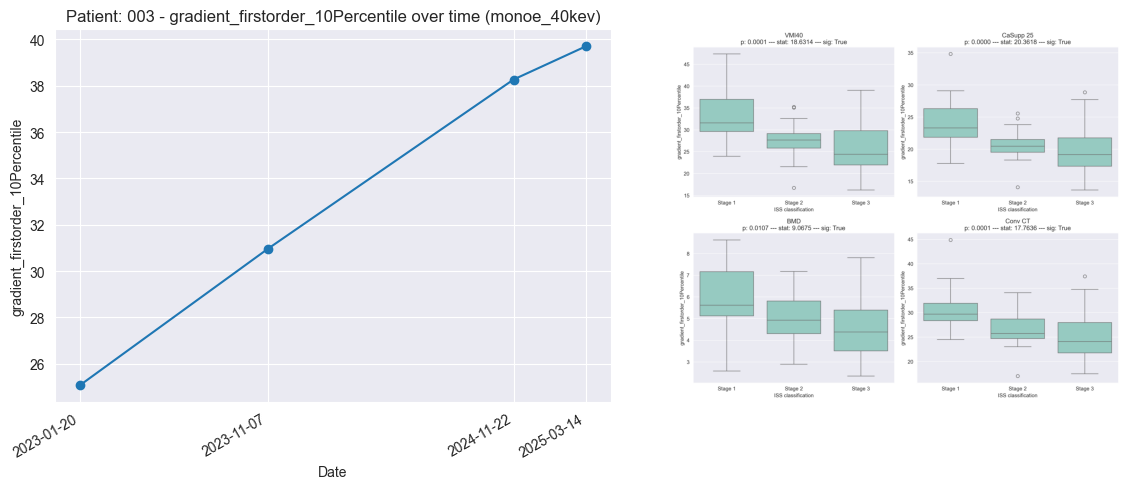

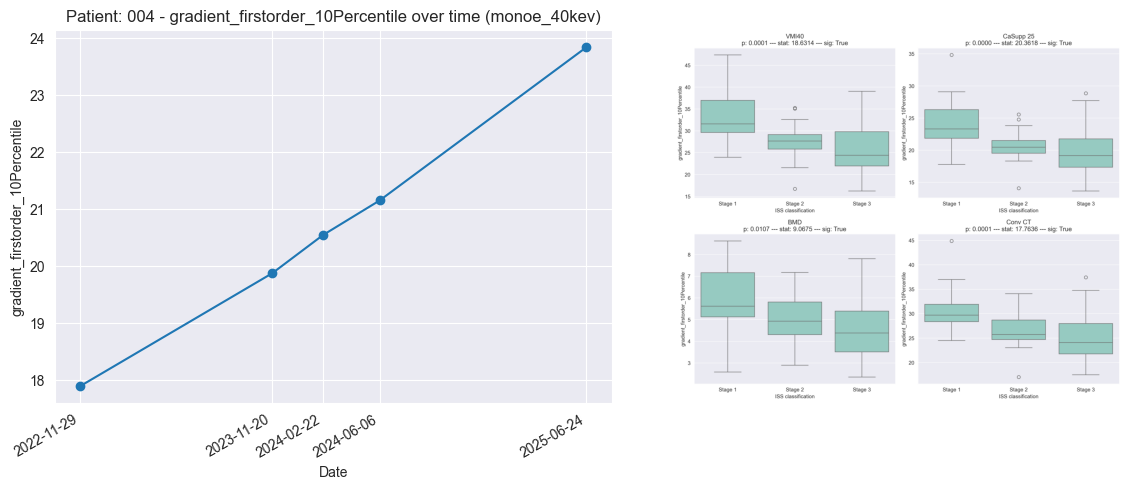

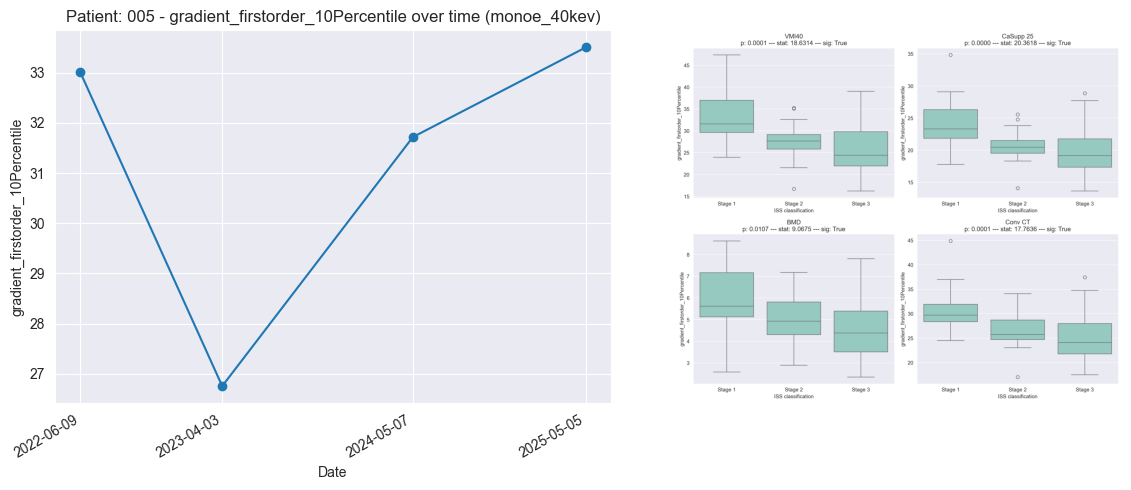

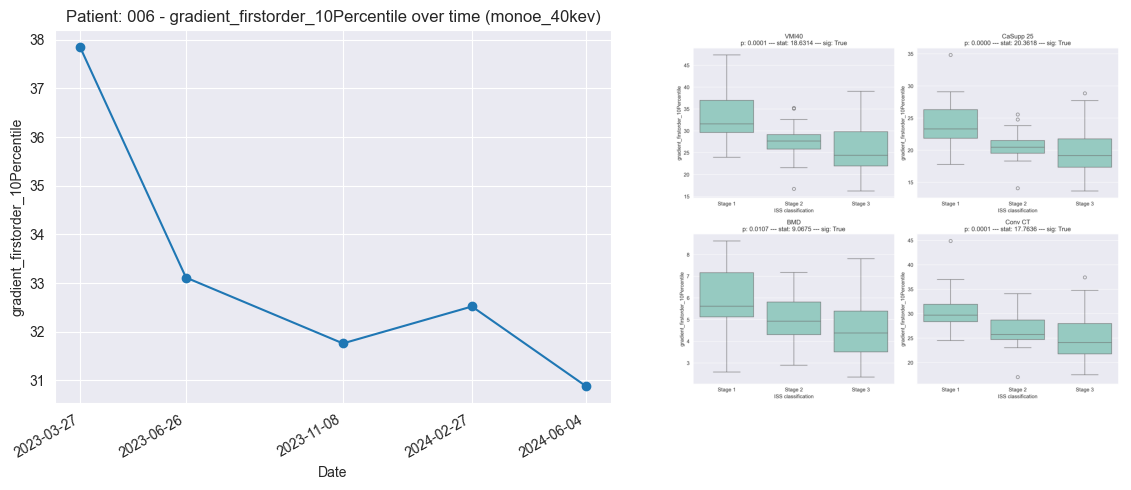

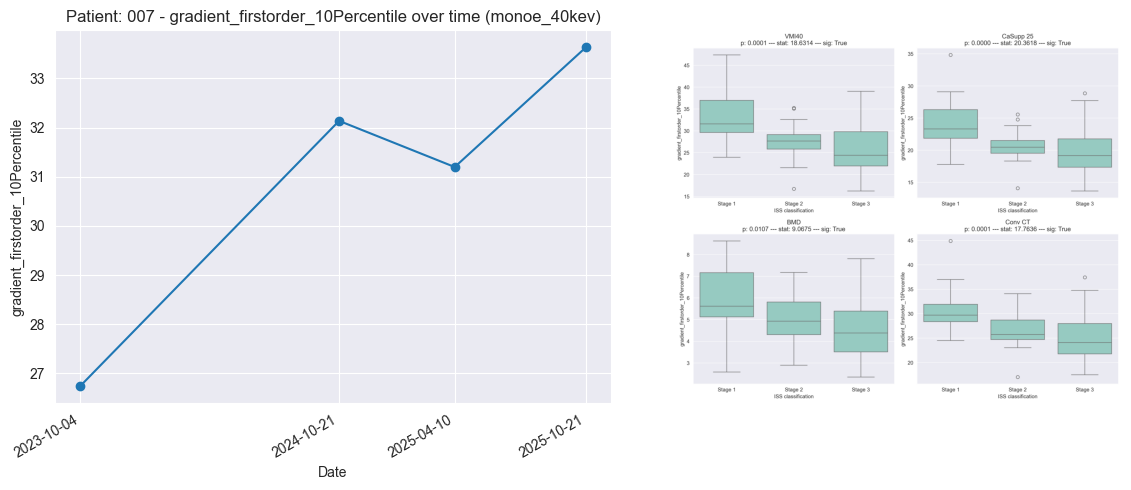

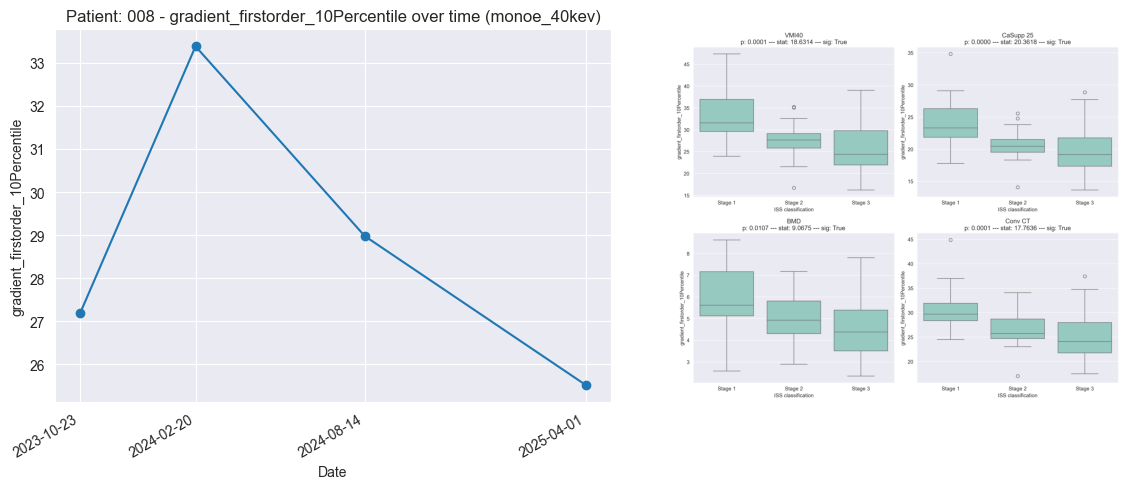

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os

image_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"
graph_path = r"E:\Graphs"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.subplot(122)
    graph = plt.imread(os.path.join(graph_path, f"{feature}.png"))
    plt.imshow(graph)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

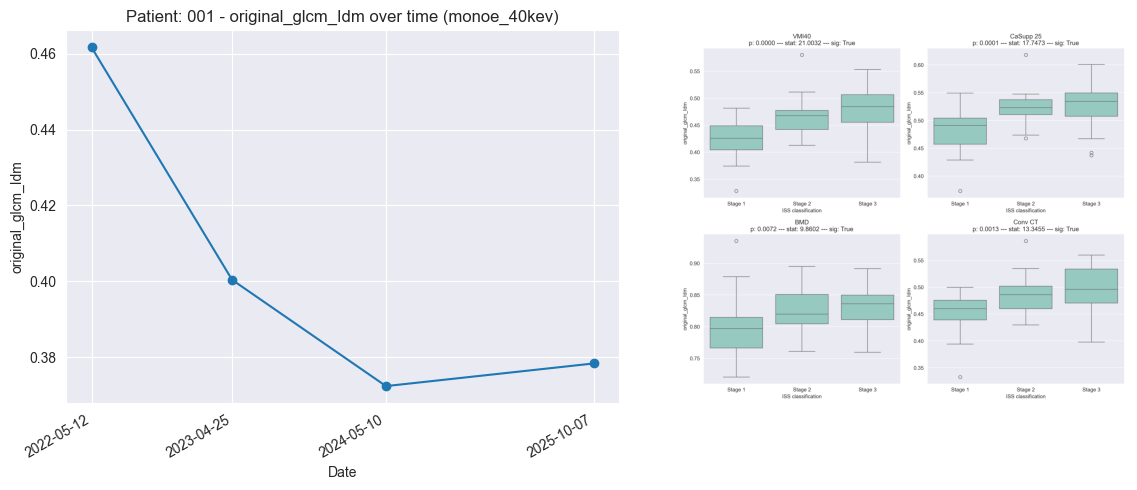

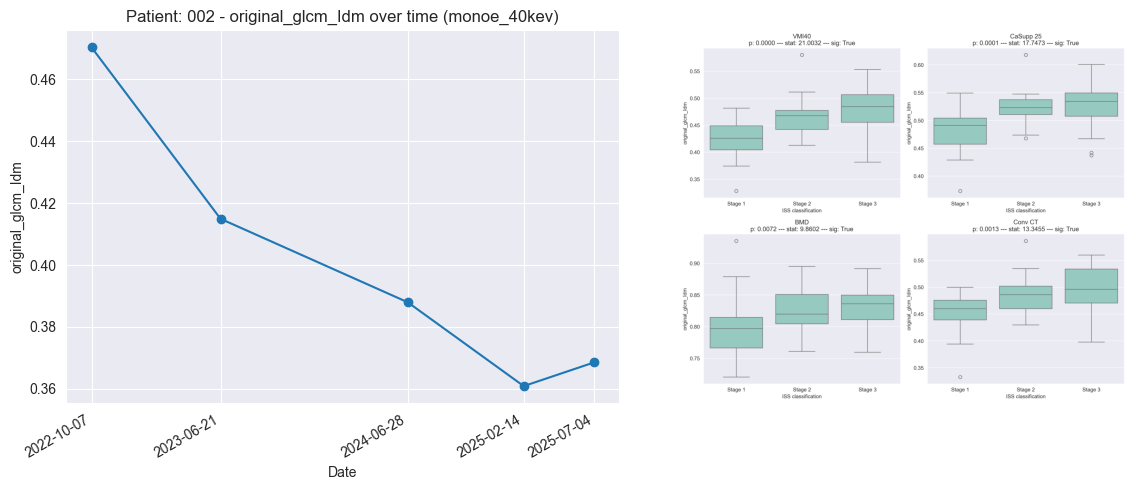

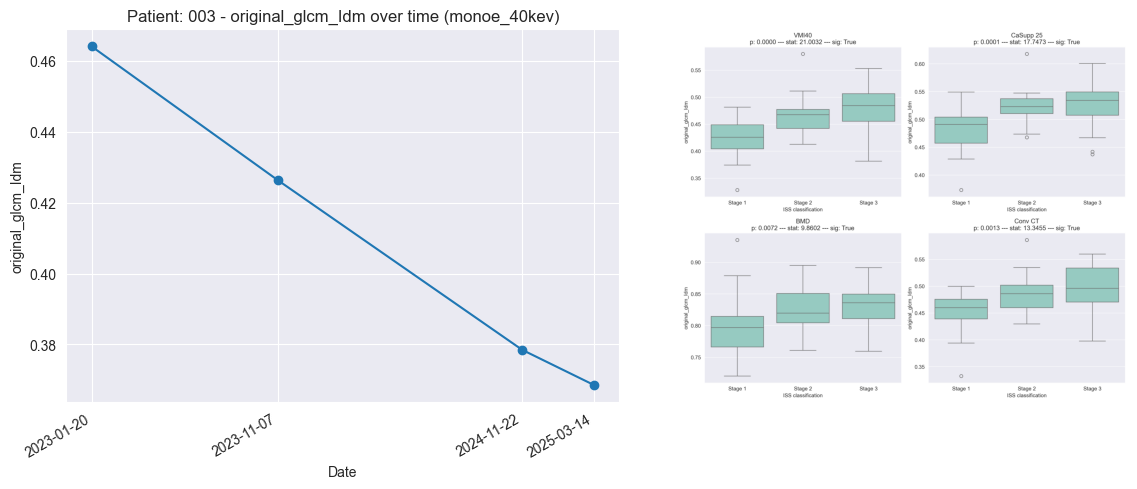

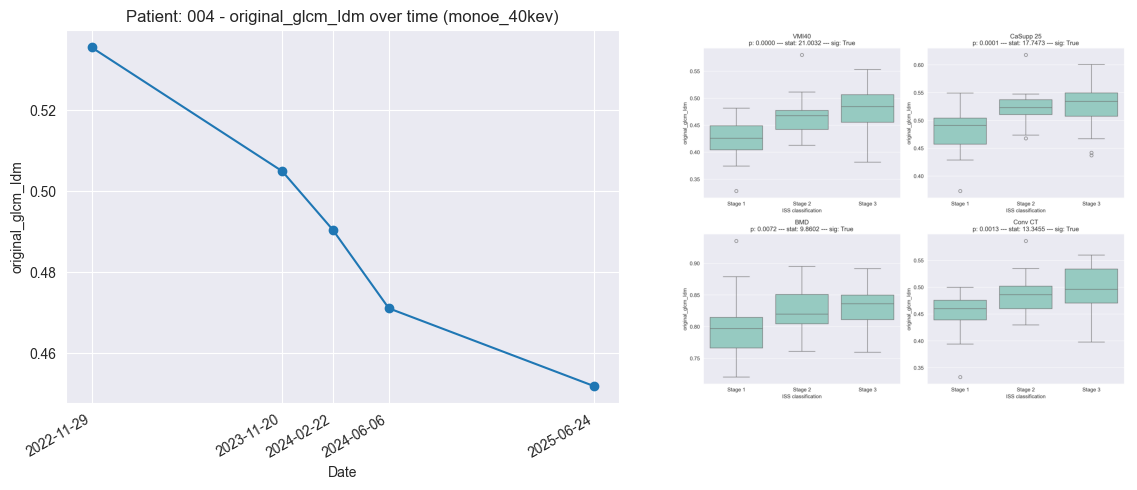

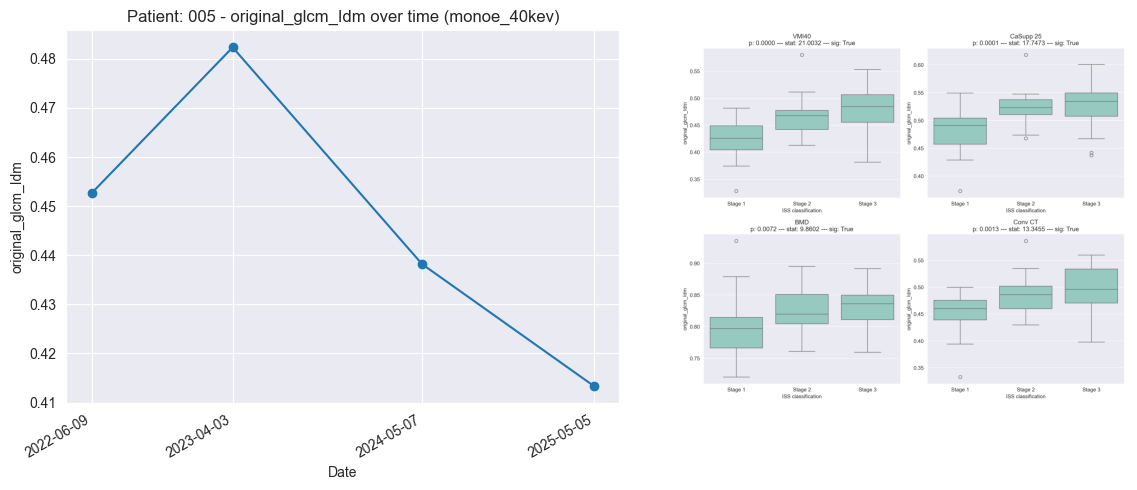

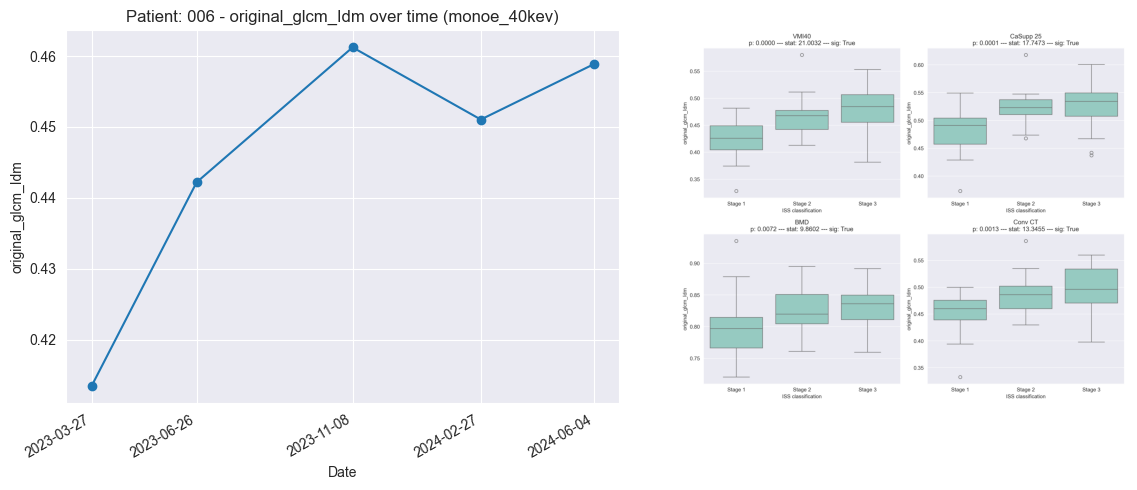

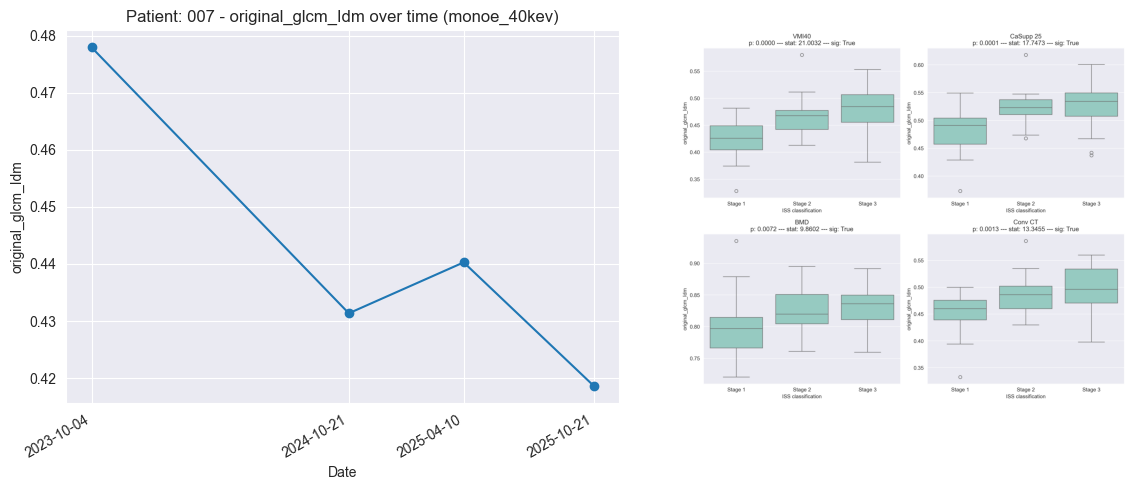

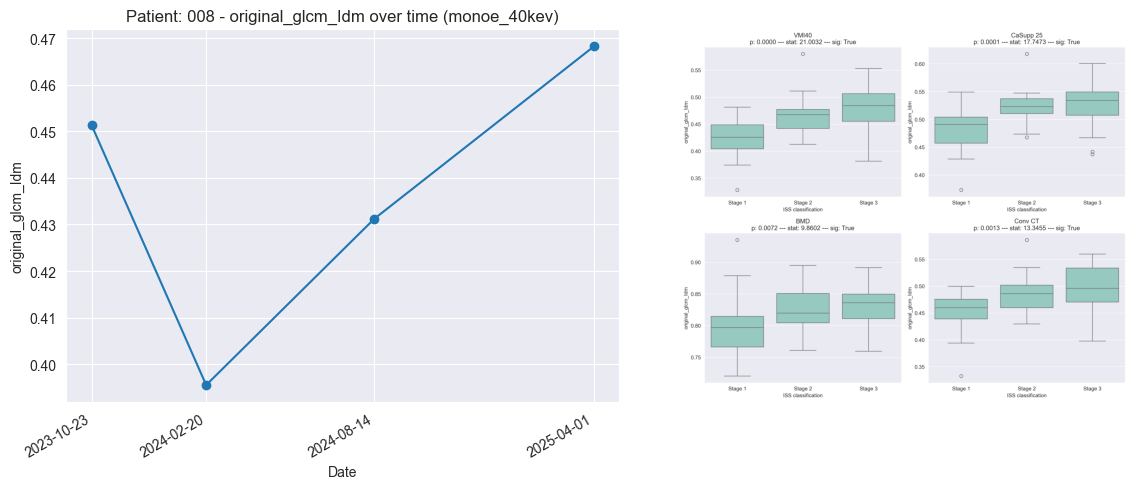

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os

image_type = "monoe_40kev"
feature = "original_glcm_Idm"
graph_path = r"E:\Graphs"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.subplot(122)
    graph = plt.imread(os.path.join(graph_path, f"{feature}.png"))
    plt.imshow(graph)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

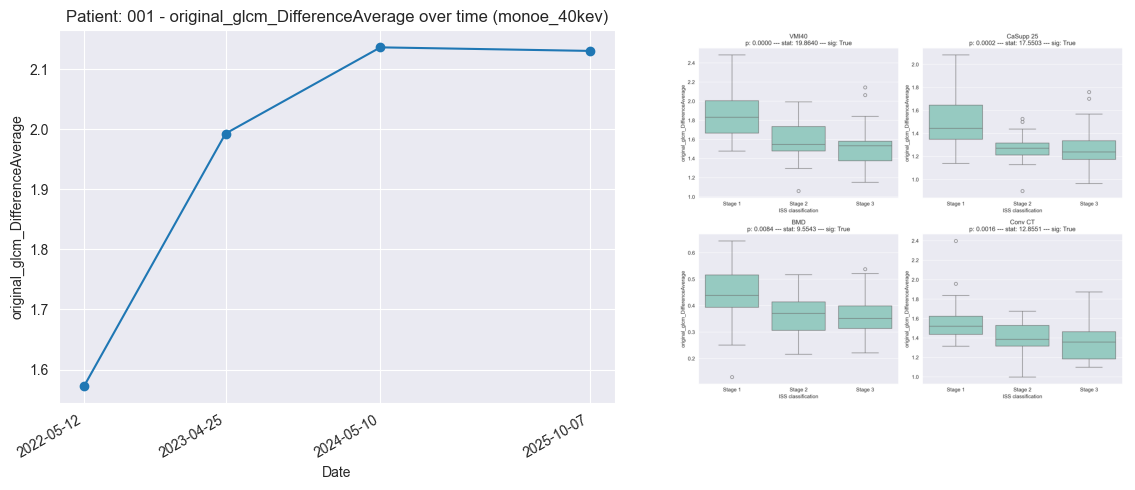

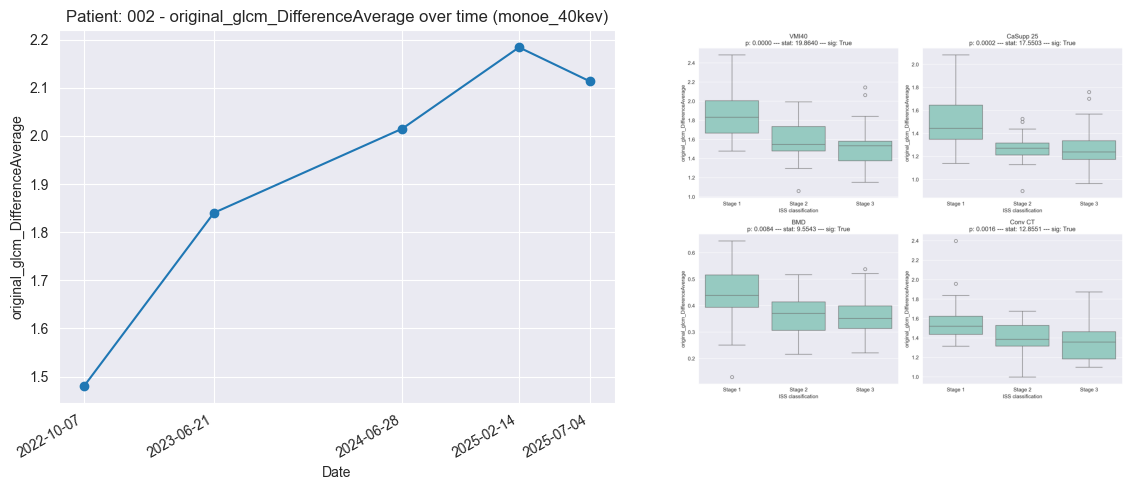

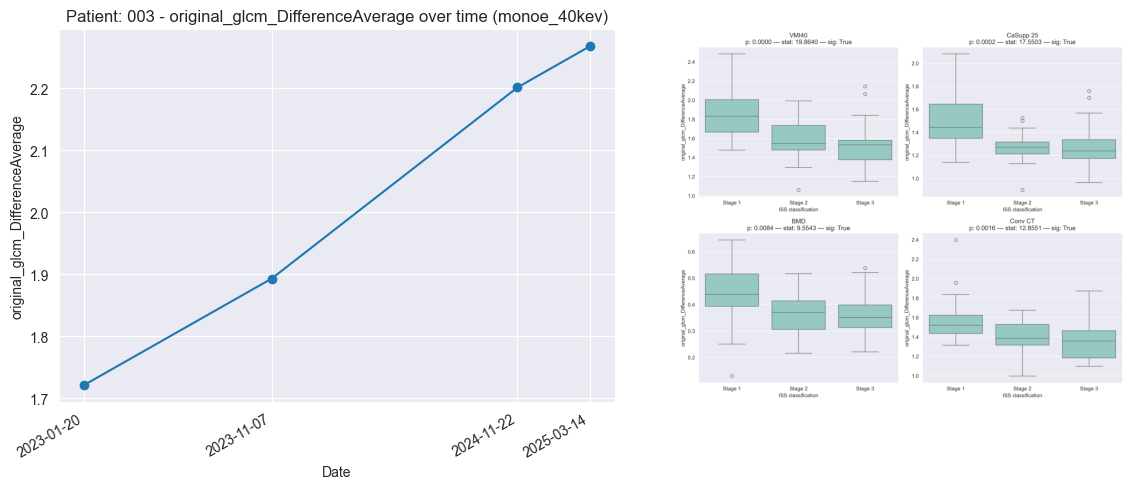

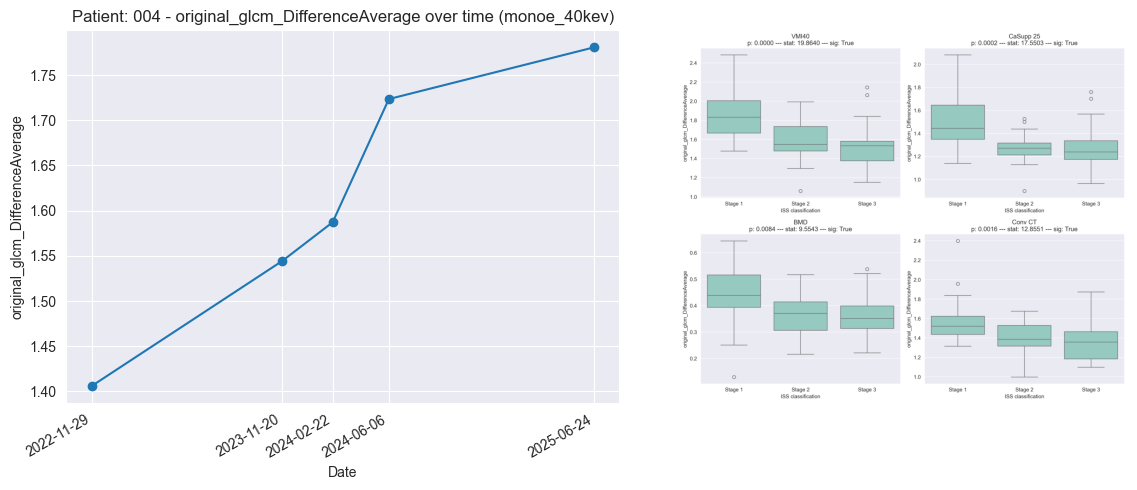

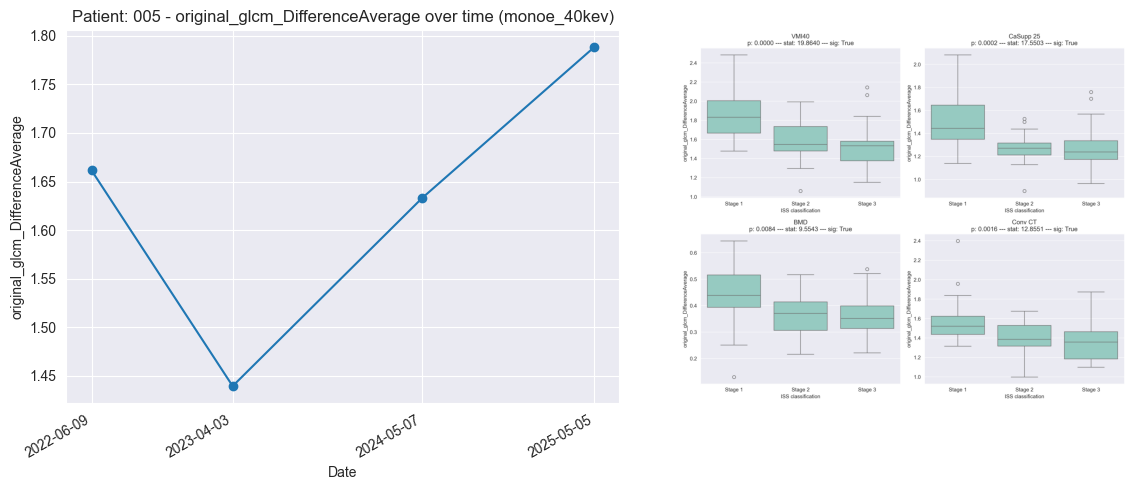

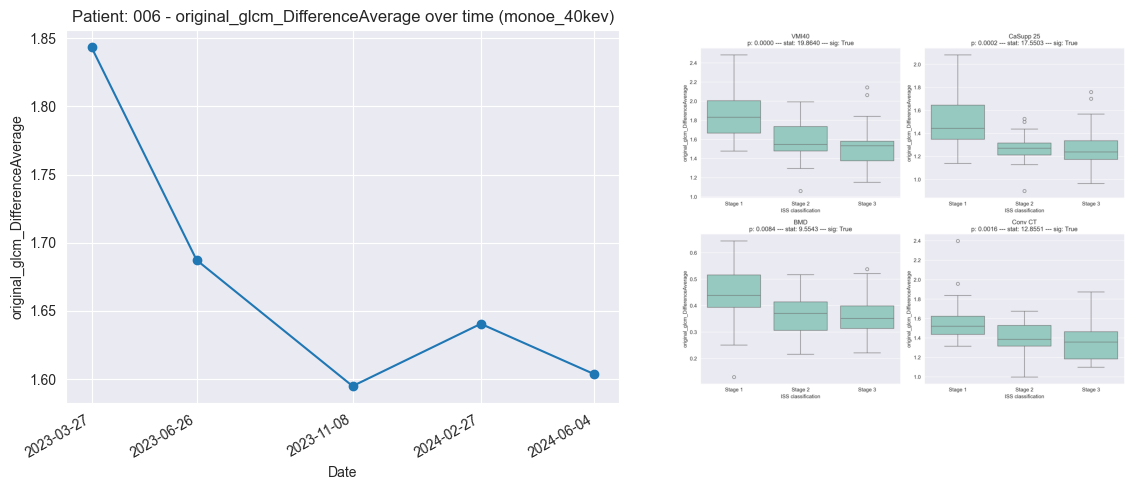

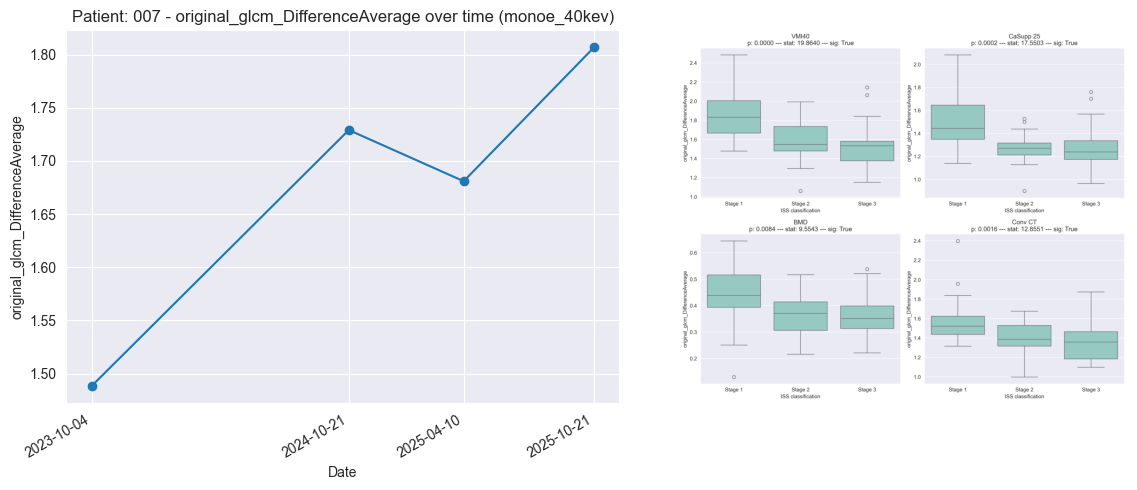

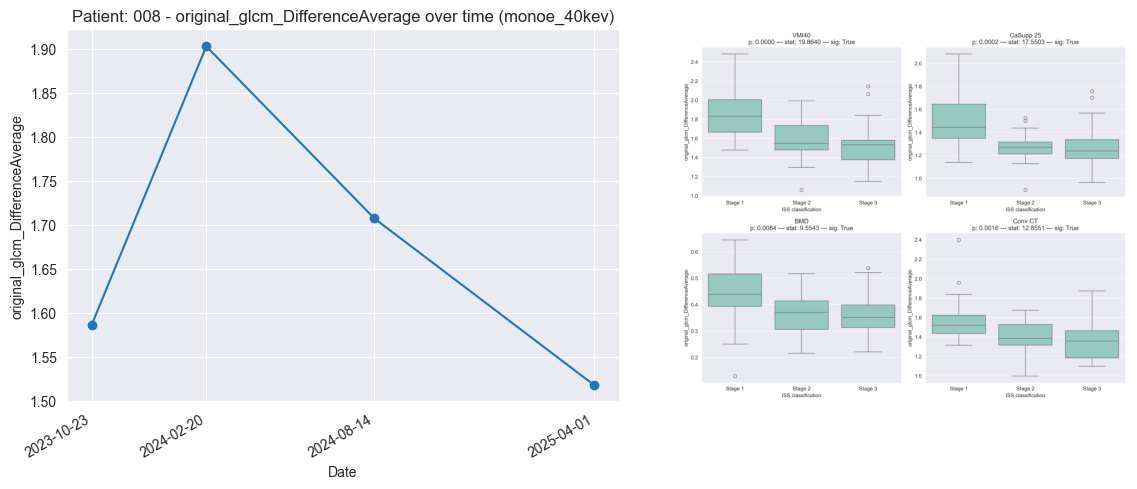

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os

image_type = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"
graph_path = r"E:\Graphs"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.subplot(122)
    graph = plt.imread(os.path.join(graph_path, f"{feature}.png"))
    plt.imshow(graph)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# SHAPE FEATURE

In [7]:
import os
import re
from collections import defaultdict

main_folder_path = r"E:\DATA_FollowUp"
patients = defaultdict(list)
pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if not match:
        continue

    patient_id = match.group(1)
    followup_number = int(match.group(2))
    folder_path = os.path.join(main_folder_path, folder)

    for file in os.listdir(folder_path):
        if file.endswith(".csv") and "konv_radiomics_individual_lesion_features" in file:
            csv_path = os.path.join(folder_path, file)
            patients[patient_id].append((followup_number, csv_path))

In [8]:
patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

import pandas as pd

patient_follow_up_dfs = {}
for patient, scans in patients.items():
    scans = sorted(scans, key=lambda x: x[0])
    rows = []

    for i, (followup, path) in enumerate(scans):
        df = pd.read_csv(path)
        shape_cols = [col for col in df.columns if "shape" in col]
        mean_features = df[shape_cols].mean()
        mean_df = mean_features.to_frame().T
        mean_df.insert(0, "Date", patient_dates[patient][i])
        rows.append(mean_df)

    patient_df = pd.concat(rows, ignore_index=True)
    patient_follow_up_dfs[patient] = patient_df

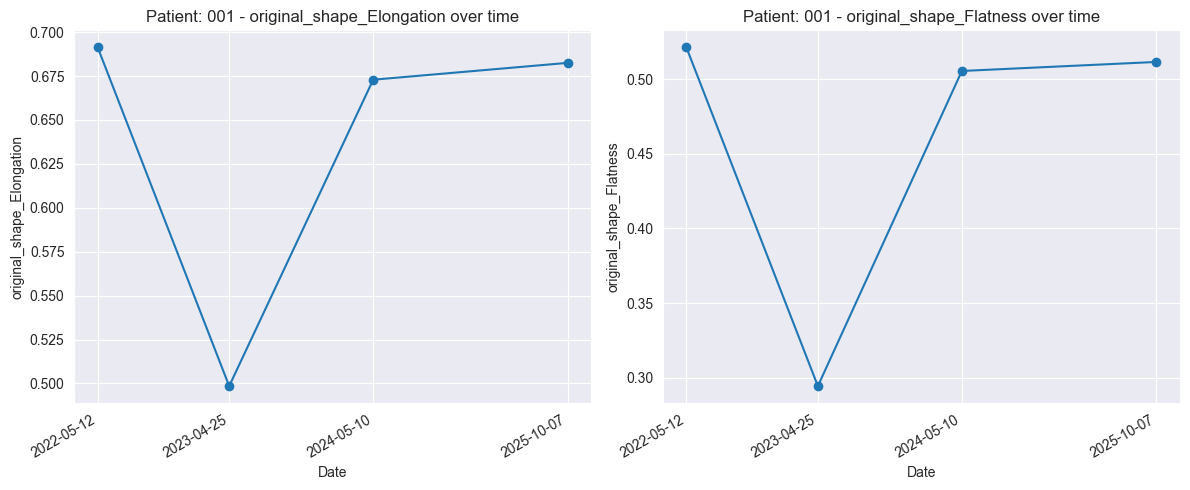

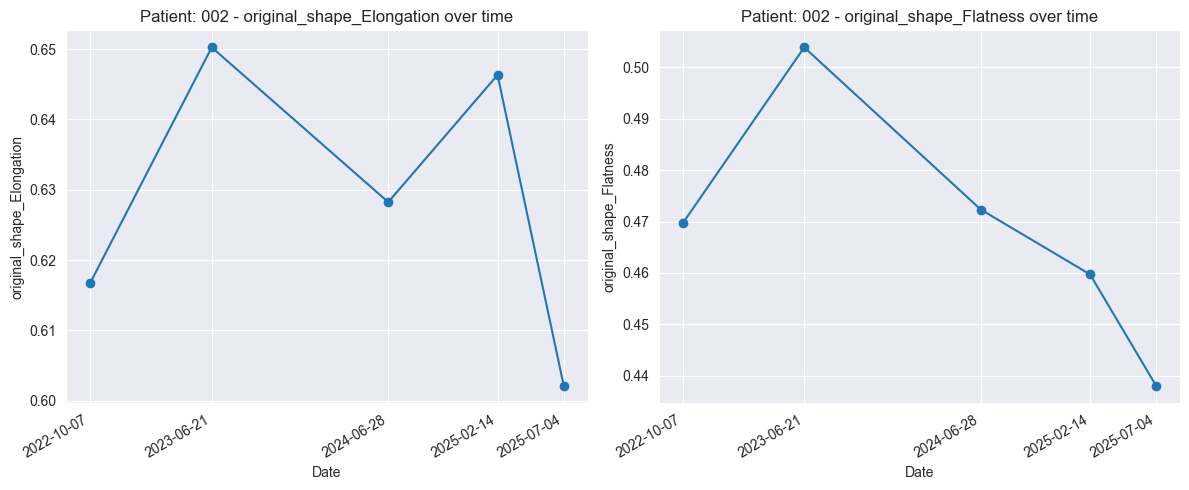

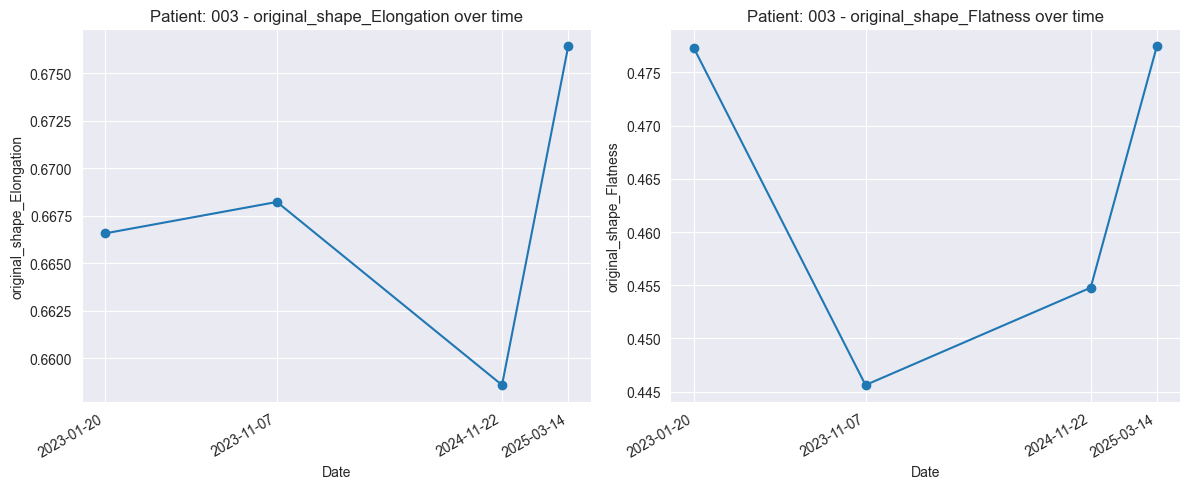

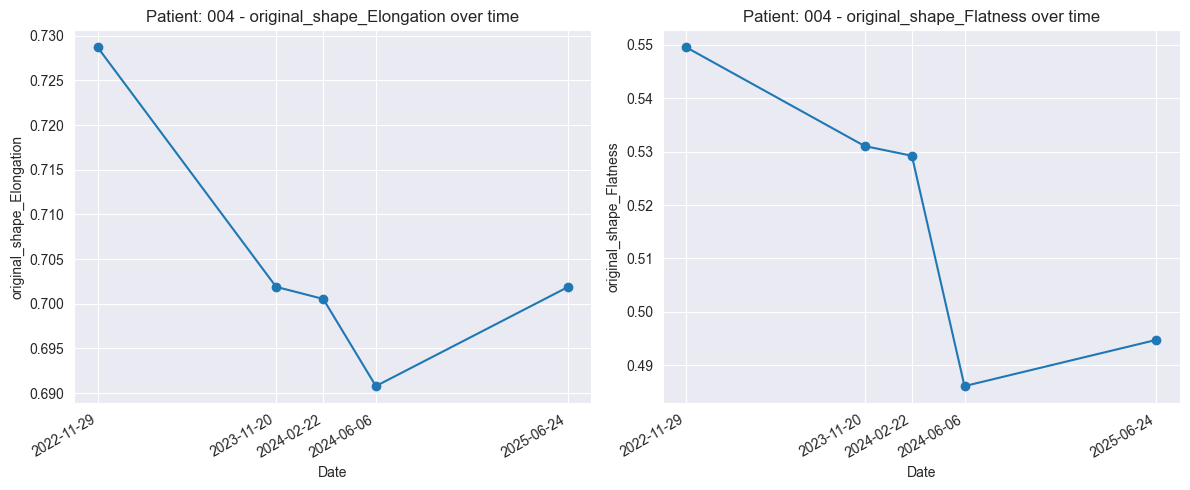

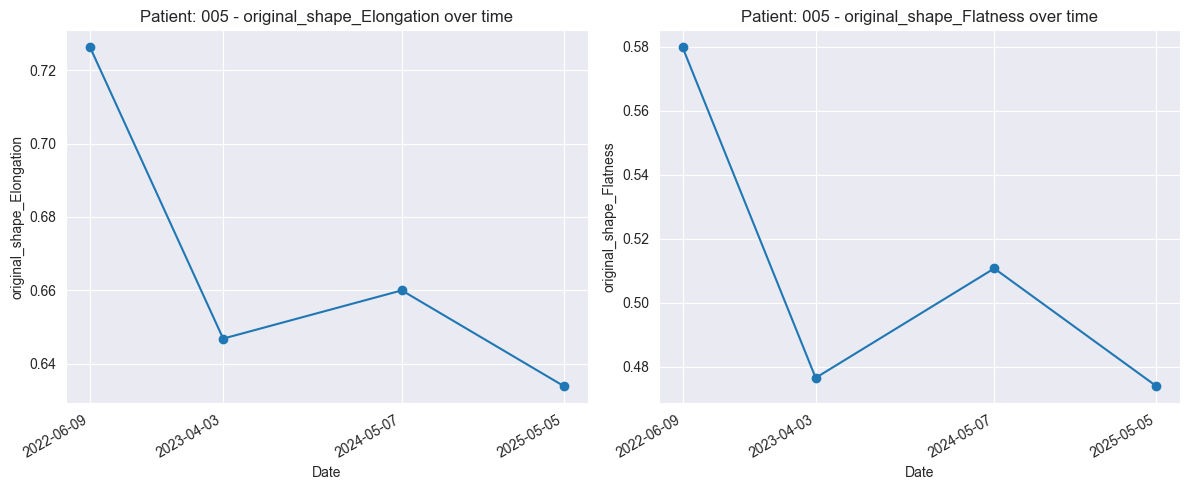

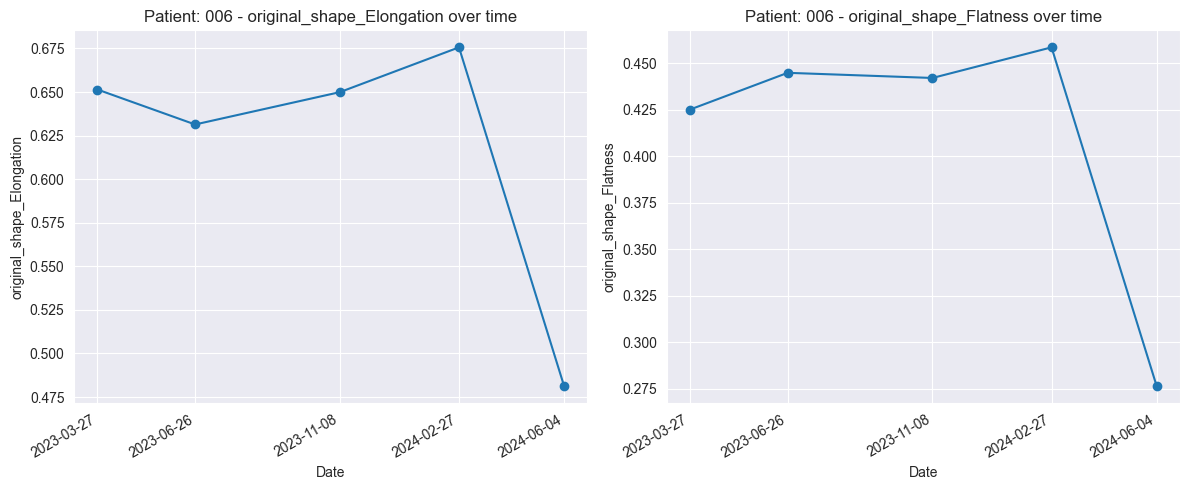

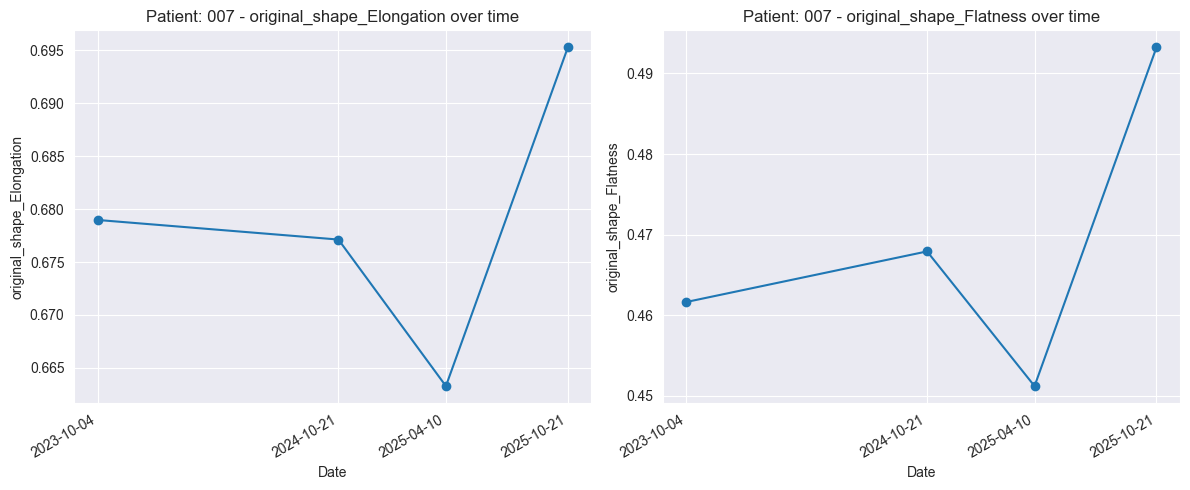

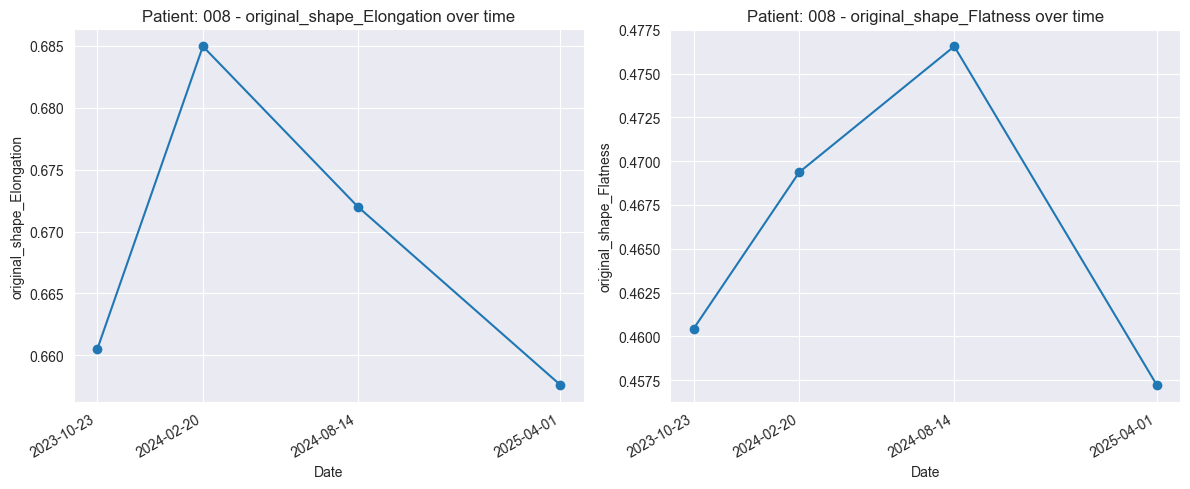

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

feature1 = "original_shape_Elongation"
feature2 = "original_shape_Flatness"

for patient, df in patient_follow_up_dfs.items():

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")

    plt.figure(figsize=(12,5))

    plt.subplot(121)
    plt.plot(df["Date"], df[feature1], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature1)
    plt.title(f"Patient: {patient} - {feature1} over time")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))

    plt.subplot(122)
    plt.plot(df["Date"], df[feature2], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature2)
    plt.title(f"Patient: {patient} - {feature2} over time")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))

    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

Všetci pacienti v jednom grafe (rovnaká osa)

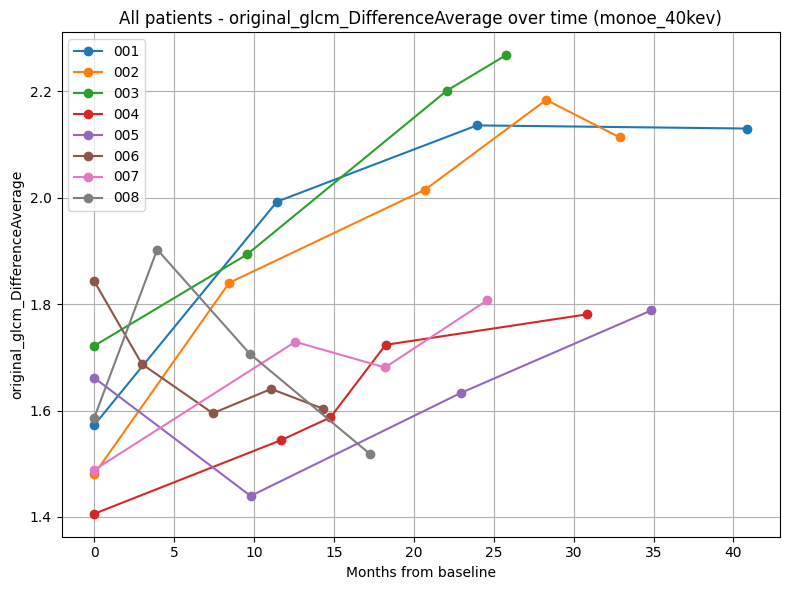

In [12]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd

image_type = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

plt.figure(figsize=(8,6))
for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    delta_months = (df["Date"] - df["Date"].iloc[0]).dt.days / 30.44
    plt.plot(delta_months, df[feature], marker="o", label=patient)

plt.xlabel("Months from baseline")
plt.ylabel(feature)
plt.title(f"All patients - {feature} over time ({image_type})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

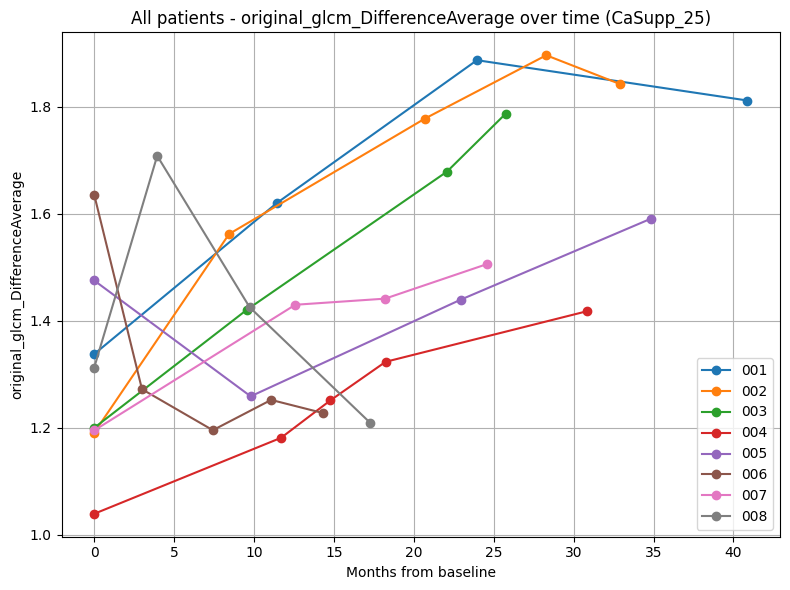

In [13]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd

image_type = "CaSupp_25"
feature = "original_glcm_DifferenceAverage"

plt.figure(figsize=(8,6))
for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    delta_months = (df["Date"] - df["Date"].iloc[0]).dt.days / 30.44
    plt.plot(delta_months, df[feature], marker="o", label=patient)

plt.xlabel("Months from baseline")
plt.ylabel(feature)
plt.title(f"All patients - {feature} over time ({image_type})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

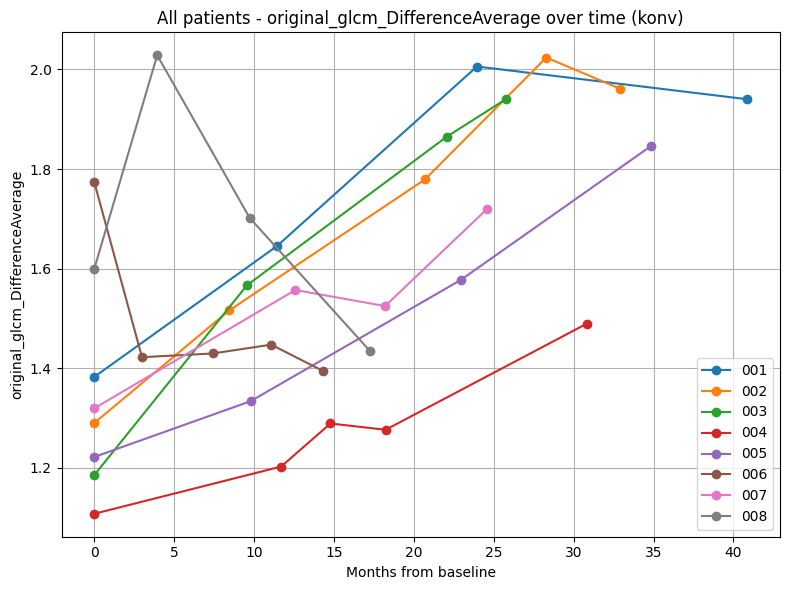

In [14]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd

image_type = "konv"
feature = "original_glcm_DifferenceAverage"

plt.figure(figsize=(8,6))
for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    delta_months = (df["Date"] - df["Date"].iloc[0]).dt.days / 30.44
    plt.plot(delta_months, df[feature], marker="o", label=patient)

plt.xlabel("Months from baseline")
plt.ylabel(feature)
plt.title(f"All patients - {feature} over time ({image_type})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()